## CHSH Inequality (proving Bell's theorem)

This tutorial demonstrate how to run the CHSH (Clauser, Horne, Shimony and Holt) inequality experiment in Braket on local simulator and a QPU for proving Bell's theorem. The notations of variables follow the reference [1].


### Background

The CHSH inequality is a Bell's inequality [2] which states that a local hidden variable theory can not reproduces the measurement outcomes of entanglement based game. For the Bell state
$$|\psi ^{-}\rangle = \frac{1}{\sqrt{2}}\left(|+-\rangle + |-+\rangle \right )$$
the CHSH inequality is given by

$$
|E(A_1,B_1) + E(A_1,B_2) + E(A_2,B_1) - E(A_2,B_2)| \leq 2
$$
for measurement settings $A_1, A_2$ on the first particle owned by Alice and settings $B_1,B_2$ on the second particle owned by Bob.

### References

[1] The Nobel Committee for Physics, Scientific Background on the Nobel Prize in Physics 2022, https://www.nobelprize.org/uploads/2022/10/advanced-physicsprize2022.pdf

[2] John F. Clauser, Michael A. Horne, Abner Shimony, and Richard A. Holt. Proposed Experiment to Test Local Hidden-Variable Theories. Phys. Rev. Lett. 23, 880 – Published 13 October 1969; Erratum Phys. Rev. Lett. 24, 549 (1970) https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.23.880

In [1]:
#Install Amazon braket

%pip install amazon-braket-sdk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.7/313.7 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.0/224.0 kB 8.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.7/191.7 kB 14.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.2/139.2 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 13.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 539.8/539.8 kB 31.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 17.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.7/82.7 kB 4.3 MB/s eta 0:00:00
  Created wheel for antlr4-python3-runtime: filename=antlr4_python3_runtime-4.9.2-py3-none-any.whl size=144548 sha256=4ef3a81b7709f8256d56a

### Running on a local simulator

In [2]:
import numpy as np
from collections import Counter
from typing import List, Tuple

# Import Braket libraries

from braket.circuits import Circuit, Qubit, circuit
from braket.devices import Device
from braket.tasks import QuantumTask

### Define the functions to create a Bell singlet state and then the circuit for CHSH inequality

In [3]:
#Define the function to prepare a Bell singlet state in Rx-rotated measurement basis

def bell_singlet_rotated_basis(
    qubit0: Qubit, qubit1: Qubit, rotation0: float, rotation1: float
) -> Circuit:
    """Prepare a Bell singlet state in a Rx-rotated meaurement basis.

    Args:
        qubit0 (Qubit): First qubit.
        qubit1 (Qubit): Second qubit.
        rotation0 (float): First qubit Rx rotation angle.
        rotation1 (float): Second qubit Rx rotation angle.

    Returns:
        Circuit: the Braket circuit that prepares the Bell circuit.
    """
    # prepare a Bell singlet state
    circ = Circuit().x(qubit0).x(qubit1).h(qubit0).cnot(qubit0, qubit1)
    if rotation0 != 0:
        circ.rx(qubit0, rotation0)
    if rotation1 != 0:
        circ.rx(qubit1, rotation1)
    circ.probability()
    return circ

In [4]:
def create_chsh_inequality_circuits(
    qubit0: Qubit = 0,
    qubit1: Qubit = 1,
    *,
    a1: float = np.pi / 2,
    a2: float = 0,
    b1: float = np.pi / 4,
    b2: float = 3 * np.pi / 4,
) -> List[Circuit]:
    """Create the four circuits for CHSH inequality. Default angles will give maximum violation of
    the inequality.

    Args:
        qubit0 (Qubit): First qubit.
        qubit1 (Qubit): Second qubit.
        a1 (float): First basis rotation angle for first qubit.
        a2 (float): Second basis rotation angle for first qubit.
        b1 (float): First basis rotation angle for second qubit.
        b2 (float): Second basis rotation angle for second qubit.

    Returns:
        List[Circuit]: List of quantum circuits.
    """
    circ_a1b1 = bell_singlet_rotated_basis(qubit0, qubit1, a1, b1)
    circ_a1b2 = bell_singlet_rotated_basis(qubit0, qubit1, a1, b2)
    circ_a2b1 = bell_singlet_rotated_basis(qubit0, qubit1, a2, b1)
    circ_a2b2 = bell_singlet_rotated_basis(qubit0, qubit1, a2, b2)
    return [circ_a1b1, circ_a1b2, circ_a2b1, circ_a2b2]

CHSH Inequality experiment consists of four circuits acting on two qubits each. The four circuits are grouped together in the `create_chsh_inequality_circuits` function. The input arguemnts are the two qubits to act on and the two separate angles to rotate each qubits by. The default values for the angles:
$$A_1 = \pi/2$$
$$B_1 = \pi/4$$
$$A_2 = 0$$
$$B_2 = 3\pi/4$$
which gives maximum violation of the CHSH inequality.

Below, we print the four CHSH circuits.

In [5]:
circuits = create_chsh_inequality_circuits(a1= np.pi / 2, a2= 0, b1= np.pi / 4,  b2=3 * np.pi / 4)

print("\ncircuit_a1b1: measurement setting for qubit0 at angle a1, qubit1 at angle b1\n",circuits[0])
print("\ncircuit_a1b2: measurement setting for qubit0 at angle a1, qubit1 at angle b2\n",circuits[1])
print("\ncircuit_a2b1: measurement setting for qubit0 at angle a2, qubit1 at angle b1\n",circuits[2])
print("\ncircuit_a2b2: measurement setting for qubit0 at angle a2, qubit1 at angle b2\n",circuits[3])


circuit_a1b1: measurement setting for qubit0 at angle a1, qubit1 at angle b1
 T  : │  0  │  1  │  2  │     3      │ Result Types  │
      ┌───┐ ┌───┐       ┌──────────┐ ┌─────────────┐ 
q0 : ─┤ X ├─┤ H ├───●───┤ Rx(1.57) ├─┤ Probability ├─
      └───┘ └───┘   │   └──────────┘ └──────┬──────┘ 
      ┌───┐       ┌─┴─┐ ┌──────────┐ ┌──────┴──────┐ 
q1 : ─┤ X ├───────┤ X ├─┤ Rx(0.79) ├─┤ Probability ├─
      └───┘       └───┘ └──────────┘ └─────────────┘ 
T  : │  0  │  1  │  2  │     3      │ Result Types  │

circuit_a1b2: measurement setting for qubit0 at angle a1, qubit1 at angle b2
 T  : │  0  │  1  │  2  │     3      │ Result Types  │
      ┌───┐ ┌───┐       ┌──────────┐ ┌─────────────┐ 
q0 : ─┤ X ├─┤ H ├───●───┤ Rx(1.57) ├─┤ Probability ├─
      └───┘ └───┘   │   └──────────┘ └──────┬──────┘ 
      ┌───┐       ┌─┴─┐ ┌──────────┐ ┌──────┴──────┐ 
q1 : ─┤ X ├───────┤ X ├─┤ Rx(2.36) ├─┤ Probability ├─
      └───┘       └───┘ └──────────┘ └─────────────┘ 
T  : │  0  │  1  │  2  │     3  

### Run the circuit on Braket local simulator

In [6]:
def run_chsh_inequality(
    circuits: List[Circuit],
    device: Device,
    shots: int = 1_000,
) -> List[QuantumTask]:
    """Submit four CHSH circuits to a device.

    Args:
        circuits (List[Circuit]): Four CHSH inequality circuits to run.
        device (Device): Quantum device or simulator.
        shots (int): Number of shots. Defaults to 1_000.

    Returns:
        List[QuantumTask]: List of quantum tasks.
    """
    tasks = [device.run(circ, shots=shots) for circ in circuits]
    return tasks

In [8]:
from braket.devices import LocalSimulator

local_tasks = run_chsh_inequality(circuits, LocalSimulator(), shots=0)

### Define funciton to get the results from CHSH

In [9]:
def get_chsh_results(
    tasks: List[QuantumTask], verbose: bool = True
) -> Tuple[float, List[Counter], float, float, float]:
    """Return CHSH task results after post-processing.

    Args:
        tasks (List[QuantumTask]): List of quantum tasks.
        verbose (bool): Controls printing of the inequality result. Defaults to True.

    Returns:
        Tuple[float, List[Counter], float, float, float]: The chsh_value, list of results,
        and the four probabilities: E_a1b1, E_a1b2, E_a2b1, E_a2b2.
    """
    results = [task.result().result_types[0].value for task in tasks]

    prob_same = np.array([d[0] + d[3] for d in results])  # 00 and 11 states
    prob_different = np.array([d[1] + d[2] for d in results])  # 01 and 10 states

    E_a1b1, E_a1b2, E_a2b1, E_a2b2 = np.array(prob_same) - np.array(prob_different)

    chsh_value = E_a1b1 + E_a1b2 + E_a2b1 - E_a2b2

    if verbose:
        print(f"E_a1b1 = {E_a1b1}, E_a1b2 = {E_a1b2}, E_a2b1 = {E_a2b1}, E_a2b2 = {E_a2b2}")
        print(f"\nCHSH inequality: {np.abs(chsh_value)} ≤ 2")

        if np.abs(chsh_value) > 2:
            print("CHSH inequality is violated!")
            print(
                "Notice that the quantity may not be exactly as predicted by Quantum theory. "
                "This is may be due to finite shots or the effects of noise on the QPU."
            )
        else:
            print("CHSH inequality is not violated.")
    return chsh_value, results, E_a1b1, E_a1b2, E_a2b1, E_a2b2

In [10]:
chsh_value, results, E_a1b1, E_a1b2, E_a2b1, E_a2b2 = get_chsh_results(local_tasks, verbose=True)

E_a1b1 = -0.7071067811865475, E_a1b2 = -0.7071067811865472, E_a2b1 = -0.7071067811865474, E_a2b2 = 0.7071067811865472

CHSH inequality: 2.828427124746189 ≤ 2
CHSH inequality is violated!
Notice that the quantity may not be exactly as predicted by Quantum theory. This is may be due to finite shots or the effects of noise on the QPU.


Notice the CHSH value is very close to $2\sqrt{2}\approx 2.828$.

### Plotting the CHSH Value against theta angle to determine which theta gives maximum violation.

In [11]:
local_simulator = LocalSimulator()
angles = np.linspace(0, 2 * np.pi, 100)

chsh_inequality_lhs_max = 0
chsh_inequality_lhs_max_theta = 0
chsh_values = []

for theta in angles:
    circuits = create_chsh_inequality_circuits(a2=0, b1=theta, a1=2 * theta, b2=3 * theta )
    local_tasks = run_chsh_inequality(circuits, local_simulator, shots=0)
    chsh_value, results, E_a1b1, E_a1b2, E_a2b1, E_a2b2 = get_chsh_results(local_tasks, verbose=False)
    if chsh_value > chsh_inequality_lhs_max:
        chsh_inequality_lhs_max = np.abs(chsh_value)
        chsh_inequality_lhs_max_theta = theta
    chsh_values.append(chsh_value)

print(
    "\nFor all the iterations:\n Max CHSH_inequality:",
    chsh_inequality_lhs_max,
    "Corresponding theta:",
    chsh_inequality_lhs_max_theta,
)


For all the iterations:
 Max CHSH_inequality: 2.8281587012240337 Corresponding theta: 2.3482611754105527


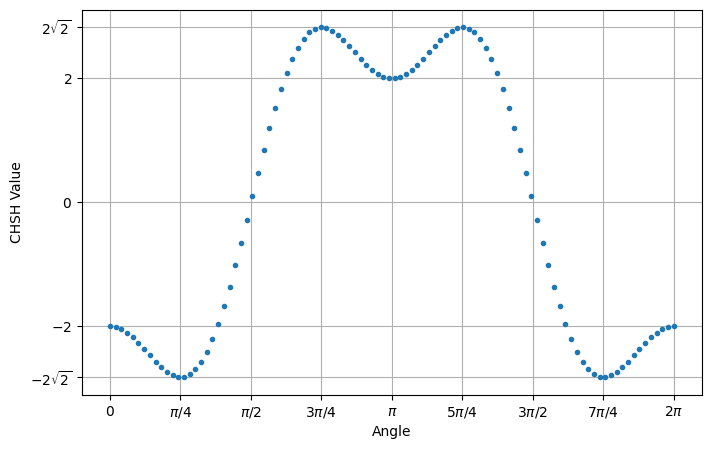

In [12]:
import matplotlib.pyplot as plt

%matplotlib inline

fig, ax = plt.subplots(figsize=(8, 5))
plt.plot(angles, chsh_values, ".", label="CHSH Value")

plt.grid(which="major", axis="both")
plt.yticks([-np.sqrt(2) * 2, -2, 0, 2, np.sqrt(2) * 2], ["$-2\sqrt{2}$", "$-2$", "$0$", "$2$", "$2\sqrt{2}$"])
plt.xticks([i*np.pi/4 for i in range(9)], ["$0$", "$\pi/4$", "$\pi/2$", "$3\pi/4$", "$\pi$","$5\pi/4$","$3\pi/2$","$7\pi/4$","$2\pi$"])

plt.xlabel("Angle")
plt.ylabel("CHSH Value");

From the plot, we see that the maximum violation is for $\theta = \pi/4$ as expected. The red line shows the classical bounds of $\text{CHSH} \leq 2$ and the dotted black line shows the quantum bound at $\text{CHSH} \leq 2\sqrt{2}$.